In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"D:\Skillify Zone Intern\Task no 02\StudentsPerformance.csv")

In [5]:
df["average_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)
df["pass_fail"] = (df["average_score"] >= 50).astype(int)

In [6]:
label_encoders = {}
categorical_columns = ["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course"]
df_encoded = df.copy()

for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

In [7]:
features = ["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course",
            "math score", "reading score", "writing score"]
X = df_encoded[features]
y = df_encoded["pass_fail"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [11]:
y_pred_log = log_reg.predict(X_test)
y_pred_tree = dtree.predict(X_test)

In [12]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n----- {model_name} -----")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

In [13]:
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_tree, "Decision Tree")


----- Logistic Regression -----
Accuracy: 1.0
Precision: 1.0
Confusion Matrix:
 [[ 27   0]
 [  0 173]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00       173

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


----- Decision Tree -----
Accuracy: 0.985
Precision: 0.9885057471264368
Confusion Matrix:
 [[ 25   2]
 [  1 172]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94        27
           1       0.99      0.99      0.99       173

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200



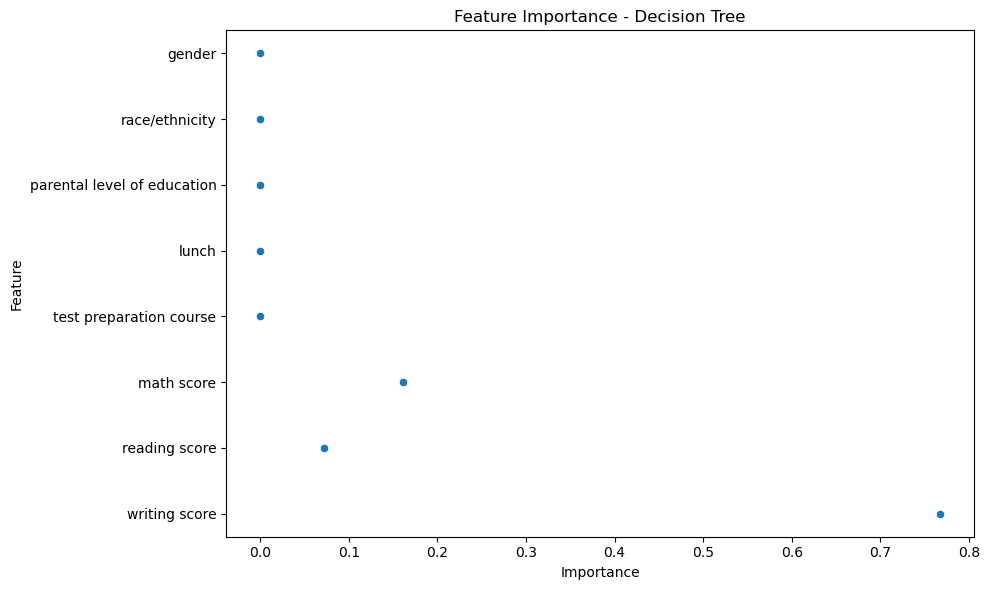

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=dtree.feature_importances_, y=features)
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()